CLEANING DATASET

In [1]:
import pandas as pd
import numpy as np
import re
import os
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

RAW_CSV = "Kelp4_dataset_1.csv"
CLEAN_CSV = "Kelp4_dataset_2.csv"

df_raw = pd.read_csv(RAW_CSV, encoding="utf-8-sig")

print("Jumlah data mentah:", len(df_raw))
print("Jumlah kolom:", len(df_raw.columns))
df_raw.head()

Jumlah data mentah: 2500
Jumlah kolom: 117


,address,categories/0,categoryName,cid,city,countryCode,fid,imageUrl,isAdvertisement,isLocalGuide,...,state,street,temporarilyClosed,text,textTranslated,title,totalScore,translatedLanguage,url,visitedIn
0,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Bakso restaurant,Bakso restaurant,11075477362009281968,Sleman Regency,ID,0x2e7a5968c9a5f589:0x99b3fffaf87195b0,https://lh3.googleusercontent.com/gps-cs-s/AHV...,False,True,...,Special Region of Yogyakarta,Jl. Colombo,False,NaN,NaN,Bakso Pa'jero,4.4,NaN,https://www.google.com/maps/search/?api=1&quer...,NaN
1,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Bakso restaurant,Bakso restaurant,11075477362009281968,Sleman Regency,ID,0x2e7a5968c9a5f589:0x99b3fffaf87195b0,https://lh3.googleusercontent.com/gps-cs-s/AHV...,False,True,...,Special Region of Yogyakarta,Jl. Colombo,False,standar~~~ baksonya ngebakso bgt,standard~~~ the meatballs are really meatballs,Bakso Pa'jero,4.4,en,https://www.google.com/maps/search/?api=1&quer...,NaN
2,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Bakso restaurant,Bakso restaurant,11075477362009281968,Sleman Regency,ID,0x2e7a5968c9a5f589:0x99b3fffaf87195b0,https://lh3.googleusercontent.com/gps-cs-s/AHV...,False,False,...,Special Region of Yogyakarta,Jl. Colombo,False,pesanan lama keluar,Orders are out for a long time,Bakso Pa'jero,4.4,en,https://www.google.com/maps/search/?api=1&quer...,NaN
3,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Bakso restaurant,Bakso restaurant,11075477362009281968,Sleman Regency,ID,0x2e7a5968c9a5f589:0x99b3fffaf87195b0,https://lh3.googleusercontent.com/gps-cs-s/AHV...,False,True,...,Special Region of Yogyakarta,Jl. Colombo,False,NaN,NaN,Bakso Pa'jero,4.4,NaN,https://www.google.com/maps/search/?api=1&quer...,NaN
4,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Bakso restaurant,Bakso restaurant,11075477362009281968,Sleman Regency,ID,0x2e7a5968c9a5f589:0x99b3fffaf87195b0,https://lh3.googleusercontent.com/gps-cs-s/AHV...,False,False,...,Special Region of Yogyakarta,Jl. Colombo,False,NaN,NaN,Bakso Pa'jero,4.4,NaN,https://www.google.com/maps/search/?api=1&quer...,NaN


In [2]:
df_raw[["reviewId", "title", "categoryName", "text", "publishedAtDate", "stars", "originalLanguage"]].head(10)

,reviewId,title,categoryName,text,publishedAtDate,stars,originalLanguage
0,Ci9DQUlRQUNvZENodHljRjlvT2s1S1JHbFplRkJoV0hKVV...,Bakso Pa'jero,Bakso restaurant,NaN,2026-04-06T14:36:22.529Z,5,NaN
1,Ci9DQUlRQUNvZENodHljRjlvT21WTVZHbFJURWwxT1daaE...,Bakso Pa'jero,Bakso restaurant,standar~~~ baksonya ngebakso bgt,2026-04-06T14:34:15.605Z,4,id
2,Ci9DQUlRQUNvZENodHljRjlvT21SUFdHMWlVbEo0TlZkSF...,Bakso Pa'jero,Bakso restaurant,pesanan lama keluar,2026-04-06T09:07:12.947Z,1,id
3,Ci9DQUlRQUNvZENodHljRjlvT205Q2NUUm9ZbE51UzFSR2...,Bakso Pa'jero,Bakso restaurant,NaN,2026-04-06T08:01:22.982Z,4,NaN
4,Ci9DQUlRQUNvZENodHljRjlvT2xWdmRYY3RRa0V0YzFWdV...,Bakso Pa'jero,Bakso restaurant,NaN,2026-04-06T03:23:02.139Z,5,NaN
5,Ci9DQUlRQUNvZENodHljRjlvT21oamJETmZOMEprZUhaMV...,Bakso Pa'jero,Bakso restaurant,"Saya kesini jam 3 sore bersama keluarga, yg sa...",2026-04-05T09:16:35.059Z,1,id
6,Ci9DQUlRQUNvZENodHljRjlvT21wTk1XNU9aekV3YzNVeV...,Bakso Pa'jero,Bakso restaurant,Bakso bakar ya enak dan pas,2026-04-05T06:30:38.109Z,5,id
7,Ci9DQUlRQUNvZENodHljRjlvT21sck1VSmtTamx2VTBWSG...,Bakso Pa'jero,Bakso restaurant,Semuanya worth bakso mozanya enak banget,2026-04-05T06:28:51.680Z,5,id
8,Ci9DQUlRQUNvZENodHljRjlvT2pjdFExaGZURmRoY1V0dm...,Bakso Pa'jero,Bakso restaurant,Mandatory after swim!!!,2026-04-05T05:22:39.690Z,5,en
9,Ci9DQUlRQUNvZENodHljRjlvT2tKM1EwNUNWRU5XU1hsRm...,Bakso Pa'jero,Bakso restaurant,NaN,2026-04-05T04:48:44.274Z,5,NaN


In [3]:
def clean_review(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[\n\r\t]", " ", text)
    text = re.sub(r"~+", " ", text)
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [4]:
df_clean = pd.DataFrame()

df_clean["review_id"] = df_raw["reviewId"]
df_clean["business_name"] = df_raw["title"]
df_clean["category"] = "Kuliner"
df_clean["review_text"] = df_raw["text"].apply(clean_review)

review_date = pd.to_datetime(df_raw["publishedAtDate"], errors="coerce", utc=True)
df_clean["review_date"] = review_date.dt.tz_convert("Asia/Jakarta").dt.strftime("%d/%m/%Y %H:%M")

df_clean["rating"] = df_raw["stars"]
df_clean["source_url"] = df_raw["reviewUrl"].fillna(df_raw["url"])
df_clean["place_id"] = df_raw["placeId"]
df_clean["address"] = df_raw["address"]
df_clean["city"] = df_raw["city"]
df_clean["original_language"] = df_raw["originalLanguage"]

df_clean.head()

,review_id,business_name,category,review_text,review_date,rating,source_url,place_id,address,city,original_language
0,Ci9DQUlRQUNvZENodHljRjlvT2s1S1JHbFplRkJoV0hKVV...,Bakso Pa'jero,Kuliner,,06/04/2026 21:36,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency,NaN
1,Ci9DQUlRQUNvZENodHljRjlvT21WTVZHbFJURWwxT1daaE...,Bakso Pa'jero,Kuliner,standar baksonya ngebakso bgt,06/04/2026 21:34,4,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency,id
2,Ci9DQUlRQUNvZENodHljRjlvT21SUFdHMWlVbEo0TlZkSF...,Bakso Pa'jero,Kuliner,pesanan lama keluar,06/04/2026 16:07,1,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency,id
3,Ci9DQUlRQUNvZENodHljRjlvT205Q2NUUm9ZbE51UzFSR2...,Bakso Pa'jero,Kuliner,,06/04/2026 15:01,4,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency,NaN
4,Ci9DQUlRQUNvZENodHljRjlvT2xWdmRYY3RRa0V0YzFWdV...,Bakso Pa'jero,Kuliner,,06/04/2026 10:23,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency,NaN


In [5]:
print("Jumlah awal:", len(df_clean))

before = len(df_clean)
df_clean = df_clean[df_clean["review_text"].notna()]
df_clean = df_clean[df_clean["review_text"].str.strip() != ""]
after = len(df_clean)

print("Setelah hapus review kosong:", after)
print("Review kosong yang dihapus:", before - after)

Jumlah awal: 2500
Setelah hapus review kosong: 1829
Review kosong yang dihapus: 671


In [6]:
before = len(df_clean)

df_clean = df_clean[df_clean["original_language"] == "id"]

after = len(df_clean)

print("Setelah hapus review bahasa Inggris/selain Indonesia:", after)
print("Data non-Indonesia yang dihapus:", before - after)

Setelah hapus review bahasa Inggris/selain Indonesia: 1707
Data non-Indonesia yang dihapus: 122


In [7]:
df_clean["word_count"] = df_clean["review_text"].apply(lambda x: len(str(x).split()))

before = len(df_clean)

df_clean = df_clean[df_clean["word_count"] >= 5]

after = len(df_clean)

print("Setelah hapus review kurang dari 5 kata:", after)
print("Review kurang dari 5 kata yang dihapus:", before - after)

Setelah hapus review kurang dari 5 kata: 1227
Review kurang dari 5 kata yang dihapus: 480


In [8]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates(subset=["review_text"])
df_clean = df_clean.drop_duplicates(subset=["review_id"])

after = len(df_clean)

print("Setelah deduplikasi:", after)
print("Duplikat yang dihapus:", before - after)

Setelah deduplikasi: 1227
Duplikat yang dihapus: 0


In [9]:
df_clean = df_clean.reset_index(drop=True)

df_clean = df_clean[
    [
        "review_id",
        "business_name",
        "category",
        "review_text",
        "review_date",
        "rating",
        "source_url",
        "place_id",
        "address",
        "city"
    ]
]

df_clean.head()

,review_id,business_name,category,review_text,review_date,rating,source_url,place_id,address,city
0,Ci9DQUlRQUNvZENodHljRjlvT21oamJETmZOMEprZUhaMV...,Bakso Pa'jero,Kuliner,"Saya kesini jam 3 sore bersama keluarga, yg sa...",05/04/2026 16:16,1,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency
1,Ci9DQUlRQUNvZENodHljRjlvT21wTk1XNU9aekV3YzNVeV...,Bakso Pa'jero,Kuliner,Bakso bakar ya enak dan pas,05/04/2026 13:30,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency
2,Ci9DQUlRQUNvZENodHljRjlvT21sck1VSmtTamx2VTBWSG...,Bakso Pa'jero,Kuliner,Semuanya worth bakso mozanya enak banget,05/04/2026 13:28,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency
3,Ci9DQUlRQUNvZENodHljRjlvT201clVXVlZUekZDUmt0RF...,Bakso Pa'jero,Kuliner,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...",05/04/2026 10:07,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency
4,Ci9DQUlRQUNvZENodHljRjlvT2s1b1p6VkRWR3R0VTJ0Q0...,Bakso Pa'jero,Kuliner,"servisnya oke banget. baru dateng, mba pelayan...",03/04/2026 13:30,5,https://www.google.com/maps/reviews/data=!4m8!...,ChIJifWlyWhZei4RsJVx-Pr_s5k,"Jl. Colombo, Karang Malang, Caturtunggal, Kec....",Sleman Regency


In [10]:
print("Jumlah dataset bersih:", len(df_clean))
print("Jumlah duplikat review_id:", df_clean["review_id"].duplicated().sum())
print("Jumlah duplikat review_text:", df_clean["review_text"].duplicated().sum())
print("Jumlah review kosong:", df_clean["review_text"].isna().sum())

df_clean["review_text"].apply(lambda x: len(str(x).split())).describe()

Jumlah dataset bersih: 1227
Jumlah duplikat review_id: 0
Jumlah duplikat review_text: 0
Jumlah review kosong: 0


count    1227.000000
mean       22.757946
std        29.203330
min         5.000000
25%         7.000000
50%        12.000000
75%        24.500000
max       276.000000
Name: review_text, dtype: float64

In [11]:
df_clean.to_csv(CLEAN_CSV, index=False, sep=";", encoding="utf-8-sig")

print("Dataset bersih berhasil disimpan sebagai:", CLEAN_CSV)

Dataset bersih berhasil disimpan sebagai: Kelp4_dataset_2.csv


EDA DATASET HASIL ANOTASI

In [12]:
# =========================
# 1. Import Library
# =========================

import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

In [13]:
# =========================
# 2. Load Dataset Anotasi
# =========================

ANNOTATION_JSONL = "Kelp4_dataset_anotasi.jsonl"

data = []

with open(ANNOTATION_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df_annot = pd.DataFrame(data)

print("Jumlah baris anotasi:", len(df_annot))
print("Jumlah kolom:", len(df_annot.columns))
print("Nama kolom:")
print(df_annot.columns.tolist())

df_annot.head()

Jumlah baris anotasi: 2118
Jumlah kolom: 13
Nama kolom:
['text', 'tokens', 'spans', '_input_hash', '_task_hash', 'options', '_view_id', 'accept', 'config', 'answer', '_timestamp', '_annotator_id', '_session_id']


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,accept,config,answer,_timestamp,_annotator_id,_session_id
0,Semuanya worth bakso mozanya enak banget,"[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...","[{'start': 0, 'end': 40, 'token_start': 0, 'to...",-832848900,-485476066,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436180,nlp4_genap2526-230712427,nlp4_genap2526-230712427
1,Bakso bakar ya enak dan pas,"[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...","[{'start': 0, 'end': 27, 'token_start': 0, 'to...",616756199,-494867163,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436292,nlp4_genap2526-230712427,nlp4_genap2526-230712427
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...","[{'start': 41, 'end': 75, 'token_start': 8, 't...",-1099850682,-1708591340,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]",{'choice_style': 'multiple'},accept,1776436302,nlp4_genap2526-230712427,nlp4_genap2526-230712427
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...","[{'start': 0, 'end': 23, 'token_start': 0, 'to...",1518700474,1889327892,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]",{'choice_style': 'multiple'},accept,1776436337,nlp4_genap2526-230712427,nlp4_genap2526-230712427
4,"servisnya oke banget. baru dateng, mba pelayan...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...","[{'start': 0, 'end': 20, 'token_start': 0, 'to...",1104821067,-1778492930,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[OUT_OF_TOPIC],{'choice_style': 'multiple'},accept,1776436409,nlp4_genap2526-230712427,nlp4_genap2526-230712427


In [14]:
# =========================
# 3. Cek Jumlah Annotator dan Review Unik
# =========================

if "_annotator_id" in df_annot.columns:
    print("Jumlah data per annotator:")
    print(df_annot["_annotator_id"].value_counts())

if "_input_hash" in df_annot.columns:
    print("\nJumlah review unik:", df_annot["_input_hash"].nunique())

Jumlah data per annotator:
_annotator_id
nlp4_genap2526-230712427    1232
nlp4_genap2526-230712245     886
Name: count, dtype: int64

Jumlah review unik: 1232


In [15]:
# =========================
# 4. Ambil Satu Anotasi per Review untuk EDA
# =========================
# Karena file anotasi berisi hasil dari lebih dari satu annotator,
# maka EDA memakai satu annotator dengan jumlah data paling banyak
# agar review yang sama tidak terhitung dua kali.

df_eda = df_annot.copy()

if "_annotator_id" in df_eda.columns and "_input_hash" in df_eda.columns:
    main_annotator = df_eda["_annotator_id"].value_counts().idxmax()
    
    df_eda = df_eda[df_eda["_annotator_id"] == main_annotator].copy()
    df_eda = df_eda.drop_duplicates(subset=["_input_hash"])

    print("Annotator yang digunakan untuk EDA:", main_annotator)
    print("Jumlah data EDA:", len(df_eda))
else:
    print("Kolom annotator atau input_hash tidak ditemukan.")
    print("Semua baris digunakan untuk EDA.")
    print("Jumlah data EDA:", len(df_eda))

df_eda.head()

Annotator yang digunakan untuk EDA: nlp4_genap2526-230712427
Jumlah data EDA: 1232


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,accept,config,answer,_timestamp,_annotator_id,_session_id
0,Semuanya worth bakso mozanya enak banget,"[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...","[{'start': 0, 'end': 40, 'token_start': 0, 'to...",-832848900,-485476066,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436180,nlp4_genap2526-230712427,nlp4_genap2526-230712427
1,Bakso bakar ya enak dan pas,"[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...","[{'start': 0, 'end': 27, 'token_start': 0, 'to...",616756199,-494867163,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436292,nlp4_genap2526-230712427,nlp4_genap2526-230712427
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...","[{'start': 41, 'end': 75, 'token_start': 8, 't...",-1099850682,-1708591340,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]",{'choice_style': 'multiple'},accept,1776436302,nlp4_genap2526-230712427,nlp4_genap2526-230712427
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...","[{'start': 0, 'end': 23, 'token_start': 0, 'to...",1518700474,1889327892,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]",{'choice_style': 'multiple'},accept,1776436337,nlp4_genap2526-230712427,nlp4_genap2526-230712427
4,"servisnya oke banget. baru dateng, mba pelayan...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...","[{'start': 0, 'end': 20, 'token_start': 0, 'to...",1104821067,-1778492930,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[OUT_OF_TOPIC],{'choice_style': 'multiple'},accept,1776436409,nlp4_genap2526-230712427,nlp4_genap2526-230712427


Distribusi Label ABSA

In [16]:
# =========================
# 5. Distribusi Label ABSA
# =========================

df_eda["accept"] = df_eda["accept"].apply(lambda x: x if isinstance(x, list) else [])

label_counts = df_eda["accept"].explode().value_counts()

print("Distribusi Label ABSA:")
label_counts

Distribusi Label ABSA:


accept
PRODUCT_POSITIVE      924
OUT_OF_TOPIC          609
PLACE_POSITIVE        300
PRODUCT_NEGATIVE      115
PLACE_NEGATIVE         99
PRICE_POSITIVE         99
PRODUCT_NEUTRAL        52
PRICE_NEGATIVE         23
PRICE_NEUTRAL          13
PLACE_NEUTRAL           5
PROMOTION_POSITIVE      4
PROMOTION_NEGATIVE      2
Name: count, dtype: int64

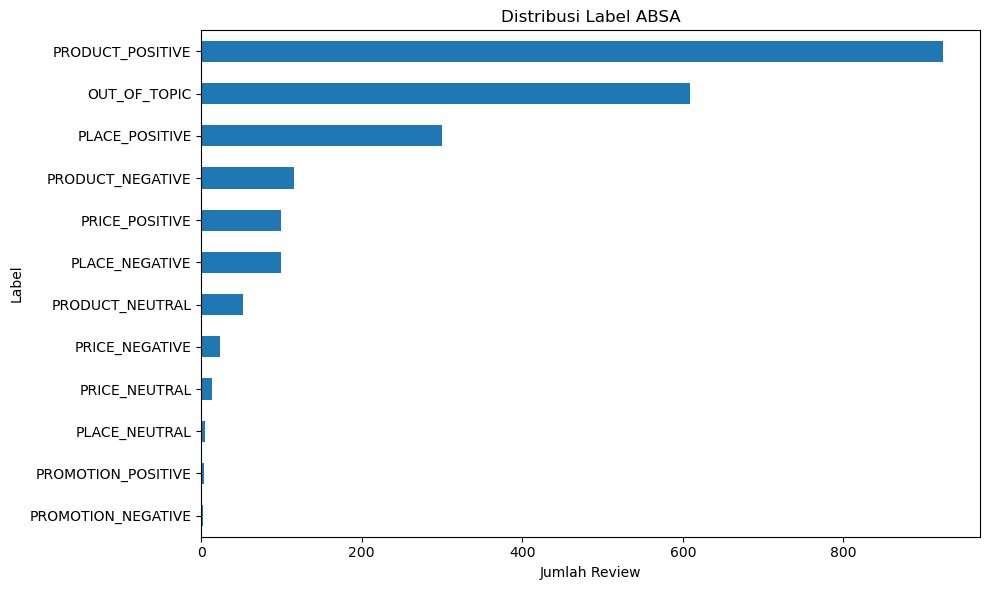

In [17]:
# Visualisasi Distribusi Label ABSA

plt.figure(figsize=(10, 6))
label_counts.sort_values().plot(kind="barh")
plt.title("Distribusi Label ABSA")
plt.xlabel("Jumlah Review")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [18]:
# Tabel Distribusi Label ABSA

label_count_df = label_counts.reset_index()
label_count_df.columns = ["label", "jumlah"]

label_count_df

,label,jumlah
0,PRODUCT_POSITIVE,924
1,OUT_OF_TOPIC,609
2,PLACE_POSITIVE,300
3,PRODUCT_NEGATIVE,115
4,PLACE_NEGATIVE,99
5,PRICE_POSITIVE,99
6,PRODUCT_NEUTRAL,52
7,PRICE_NEGATIVE,23
8,PRICE_NEUTRAL,13
9,PLACE_NEUTRAL,5


Distribusi Entitas ABSA

In [19]:
# =========================
# 6. Membuat DataFrame Entitas dari Spans
# =========================

entities = []

for _, row in df_eda.iterrows():
    text = row.get("text", "")
    spans = row.get("spans", [])

    if not isinstance(spans, list):
        continue

    for span in spans:
        start = span.get("start")
        end = span.get("end")
        label = span.get("label")

        if start is not None and end is not None:
            entity_text = text[start:end]

            entities.append({
                "entity_text": entity_text,
                "entity_label": label,
                "start": start,
                "end": end,
                "review_text": text
            })

entity_df = pd.DataFrame(entities)

print("Jumlah entitas ABSA:", len(entity_df))
entity_df.head()

Jumlah entitas ABSA: 2862


,entity_text,entity_label,start,end,review_text
0,Semuanya worth bakso mozanya enak banget,PRODUCT_POSITIVE,0,40,Semuanya worth bakso mozanya enak banget
1,Bakso bakar ya enak dan pas,PRODUCT_POSITIVE,0,27,Bakso bakar ya enak dan pas
2,"yg saya suka pelayanan disini oke,",OUT_OF_TOPIC,41,75,"Saya kesini jam 3 sore bersama keluarga, yg sa..."
3,semua pelayan ketika ada makanan yg kelewat at...,OUT_OF_TOPIC,76,163,"Saya kesini jam 3 sore bersama keluarga, yg sa..."
4,semua pelayanannya muslim,OUT_OF_TOPIC,164,189,"Saya kesini jam 3 sore bersama keluarga, yg sa..."


In [20]:
# =========================
# 7. Distribusi Entitas Berdasarkan Label
# =========================

entity_label_counts = entity_df["entity_label"].value_counts()

print("Distribusi Entitas ABSA:")
entity_label_counts

Distribusi Entitas ABSA:


entity_label
PRODUCT_POSITIVE      1086
OUT_OF_TOPIC           953
PLACE_POSITIVE         334
PRODUCT_NEGATIVE       149
PLACE_NEGATIVE         131
PRICE_POSITIVE          99
PRODUCT_NEUTRAL         58
PRICE_NEGATIVE          27
PRICE_NEUTRAL           11
PLACE_NEUTRAL            7
PROMOTION_POSITIVE       5
PROMOTION_NEGATIVE       2
Name: count, dtype: int64

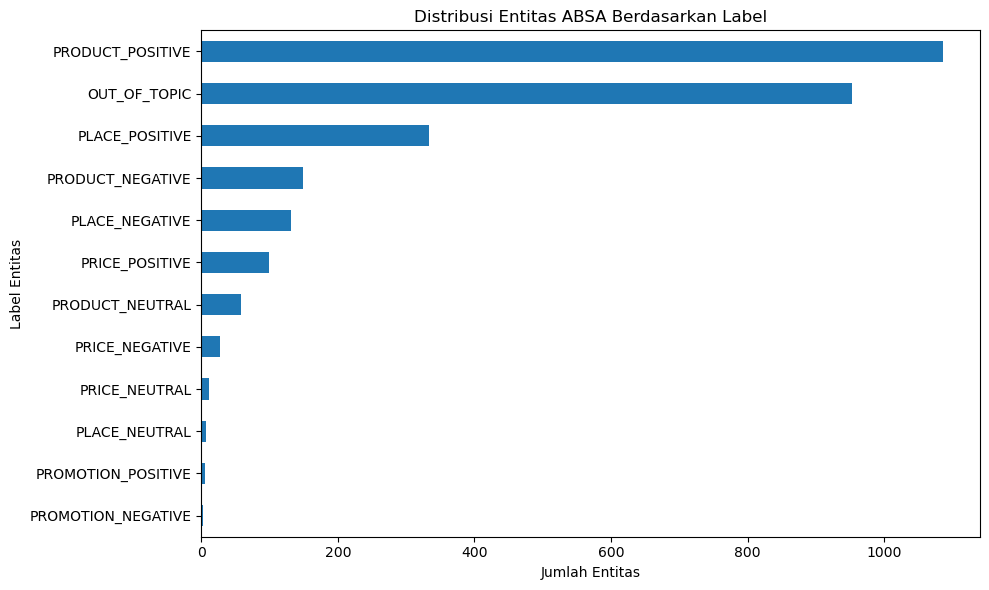

In [21]:
# Visualisasi Distribusi Entitas ABSA

plt.figure(figsize=(10, 6))
entity_label_counts.sort_values().plot(kind="barh")
plt.title("Distribusi Entitas ABSA Berdasarkan Label")
plt.xlabel("Jumlah Entitas")
plt.ylabel("Label Entitas")
plt.tight_layout()
plt.show()

In [22]:
# =========================
# 8. Top 20 Entitas yang Paling Sering Muncul
# =========================

top_entities = entity_df["entity_text"].str.lower().value_counts().head(20)

print("Top 20 Entitas ABSA:")
top_entities

Top 20 Entitas ABSA:


entity_text
baksonya enak              22
makanannya enak            16
pelayanan cepat            12
tempatnya nyaman           11
makanan enak               10
bakso nya enak              8
pelayanan ramah             7
enak                        6
tempatnya luas              6
harga terjangkau            6
tempat bersih               5
rasa enak                   4
pelayanan oke               4
suasana nyaman              3
harganya terjangkau         3
enak banget                 3
pelayanan nya ramah         3
rasanya enak                3
pelayanannya juga cepat     3
pelayanan cepat,            3
Name: count, dtype: int64

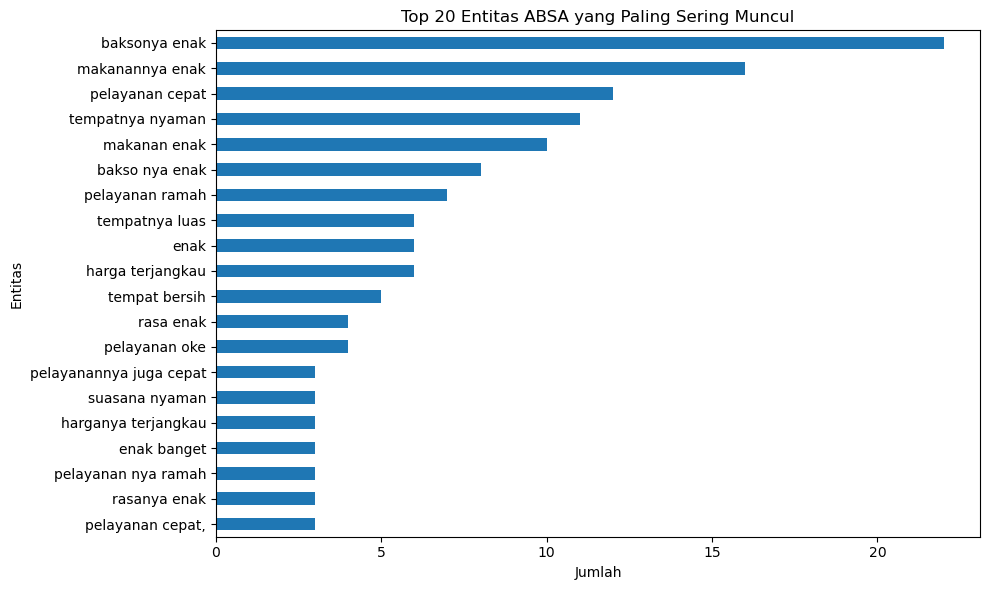

In [23]:
# Visualisasi Top 20 Entitas

plt.figure(figsize=(10, 6))
top_entities.sort_values().plot(kind="barh")
plt.title("Top 20 Entitas ABSA yang Paling Sering Muncul")
plt.xlabel("Jumlah")
plt.ylabel("Entitas")
plt.tight_layout()
plt.show()

Distribusi Panjang Review

In [24]:
# =========================
# 9. Hitung Panjang Review
# =========================

df_eda["word_count"] = df_eda["text"].apply(lambda x: len(str(x).split()))
df_eda["char_count"] = df_eda["text"].apply(lambda x: len(str(x)))

df_eda[["text", "word_count", "char_count"]].head()

,text,word_count,char_count
0,Semuanya worth bakso mozanya enak banget,6,40
1,Bakso bakar ya enak dan pas,6,27
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...",111,721
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...",33,166
4,"servisnya oke banget. baru dateng, mba pelayan...",14,94


In [25]:
# Statistik Panjang Review Berdasarkan Jumlah Kata

df_eda["word_count"].describe()

count    1232.000000
mean       22.609578
std        29.033934
min         5.000000
25%         7.000000
50%        12.000000
75%        24.000000
max       276.000000
Name: word_count, dtype: float64

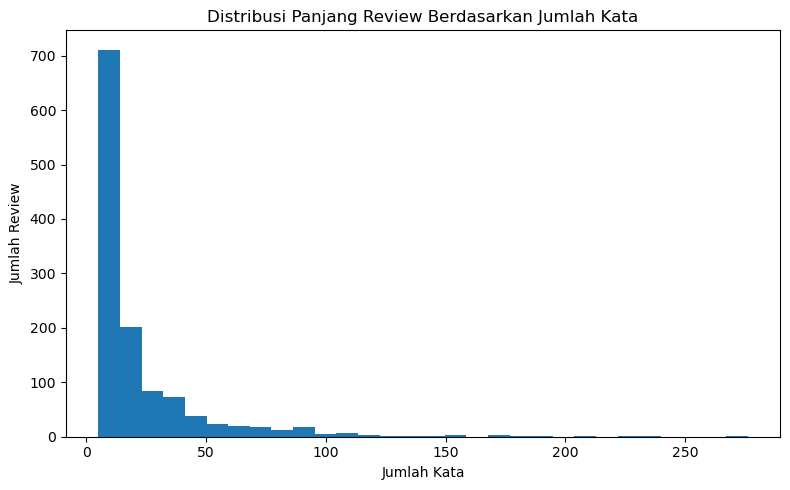

In [26]:
# Visualisasi Histogram Panjang Review

plt.figure(figsize=(8, 5))
plt.hist(df_eda["word_count"], bins=30)
plt.title("Distribusi Panjang Review Berdasarkan Jumlah Kata")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.show()

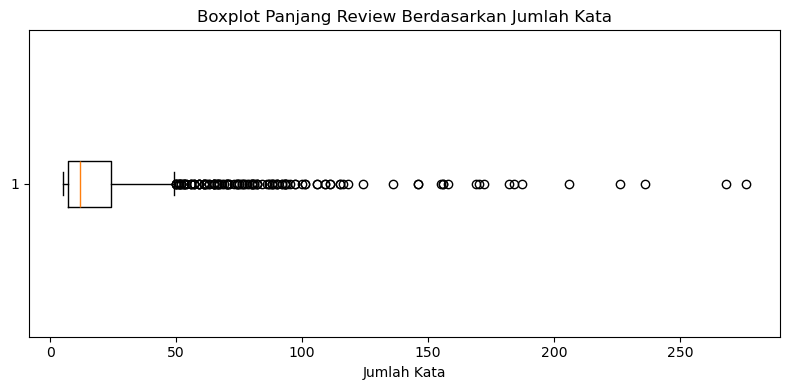

In [27]:
# Visualisasi Boxplot Panjang Review

plt.figure(figsize=(8, 4))
plt.boxplot(df_eda["word_count"], vert=False)
plt.title("Boxplot Panjang Review Berdasarkan Jumlah Kata")
plt.xlabel("Jumlah Kata")
plt.tight_layout()
plt.show()

Statistik jumlah token:
count    1232.000000
mean       26.637987
std        34.217094
min         5.000000
25%         9.000000
50%        15.000000
75%        29.000000
max       318.000000
Name: token_count, dtype: float64


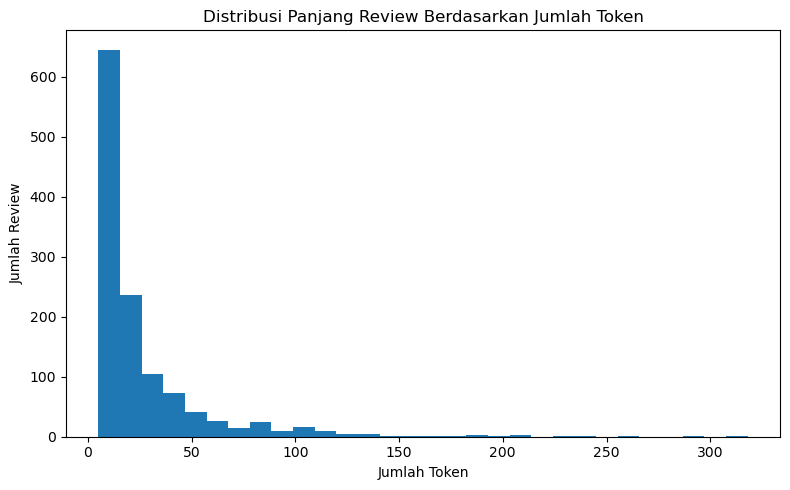

In [28]:
# Distribusi Panjang Review Berdasarkan Token jika kolom tokens tersedia

if "tokens" in df_eda.columns:
    df_eda["token_count"] = df_eda["tokens"].apply(lambda x: len(x) if isinstance(x, list) else 0)

    print("Statistik jumlah token:")
    print(df_eda["token_count"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(df_eda["token_count"], bins=30)
    plt.title("Distribusi Panjang Review Berdasarkan Jumlah Token")
    plt.xlabel("Jumlah Token")
    plt.ylabel("Jumlah Review")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom tokens tidak tersedia, analisis token dilewati.")

Matriks Korelasi Antar Label

In [29]:
# =========================
# 10. Ubah Multi-label menjadi Format Biner
# =========================

mlb = MultiLabelBinarizer()

label_matrix = mlb.fit_transform(df_eda["accept"])
label_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

label_df.head()

,OUT_OF_TOPIC,PLACE_NEGATIVE,PLACE_NEUTRAL,PLACE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PRICE_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRODUCT_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_POSITIVE
0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0
2,1,1,0,0,0,0,0,1,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0


In [30]:
# =========================
# 11. Hitung Korelasi Antar Label
# =========================

corr_matrix = label_df.corr()

corr_matrix

,OUT_OF_TOPIC,PLACE_NEGATIVE,PLACE_NEUTRAL,PLACE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PRICE_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRODUCT_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_POSITIVE
OUT_OF_TOPIC,1.000000,0.036206,-0.012042,0.070752,0.031554,0.040895,-0.005599,0.045501,0.002386,-0.257762,0.000458,0.029187
PLACE_NEGATIVE,0.036206,1.000000,0.028095,-0.077270,0.135707,0.027917,-0.021477,0.130953,0.145851,-0.091366,0.062247,-0.016871
PLACE_NEUTRAL,-0.012042,0.028095,1.000000,-0.006471,-0.008805,-0.006592,-0.018870,0.023404,-0.013401,0.036855,-0.002574,-0.003643
PLACE_POSITIVE,0.070752,-0.077270,-0.006471,1.000000,-0.022365,0.015444,0.103607,-0.045527,-0.053259,0.122289,-0.022878,0.067351
PRICE_NEGATIVE,0.031554,0.135707,-0.008805,-0.022365,1.000000,0.044446,-0.040771,0.120654,0.120174,-0.058859,0.143397,-0.007872
PRICE_NEUTRAL,0.040895,0.027917,-0.006592,0.015444,0.044446,1.000000,-0.001305,0.021477,0.017830,-0.013759,-0.004164,-0.005894
PRICE_POSITIVE,-0.005599,-0.021477,-0.018870,0.103607,-0.040771,-0.001305,1.000000,-0.053793,-0.017502,0.094813,-0.011920,0.035616
PRODUCT_NEGATIVE,0.045501,0.130953,0.023404,-0.045527,0.120654,0.021477,-0.053793,1.000000,0.113043,-0.182030,-0.012939,-0.018313
PRODUCT_NEUTRAL,0.002386,0.145851,-0.013401,-0.053259,0.120174,0.017830,-0.017502,0.113043,1.000000,-0.130522,-0.008465,-0.011981
PRODUCT_POSITIVE,-0.257762,-0.091366,0.036855,0.122289,-0.058859,-0.013759,0.094813,-0.182030,-0.130522,1.000000,-0.069843,0.032951


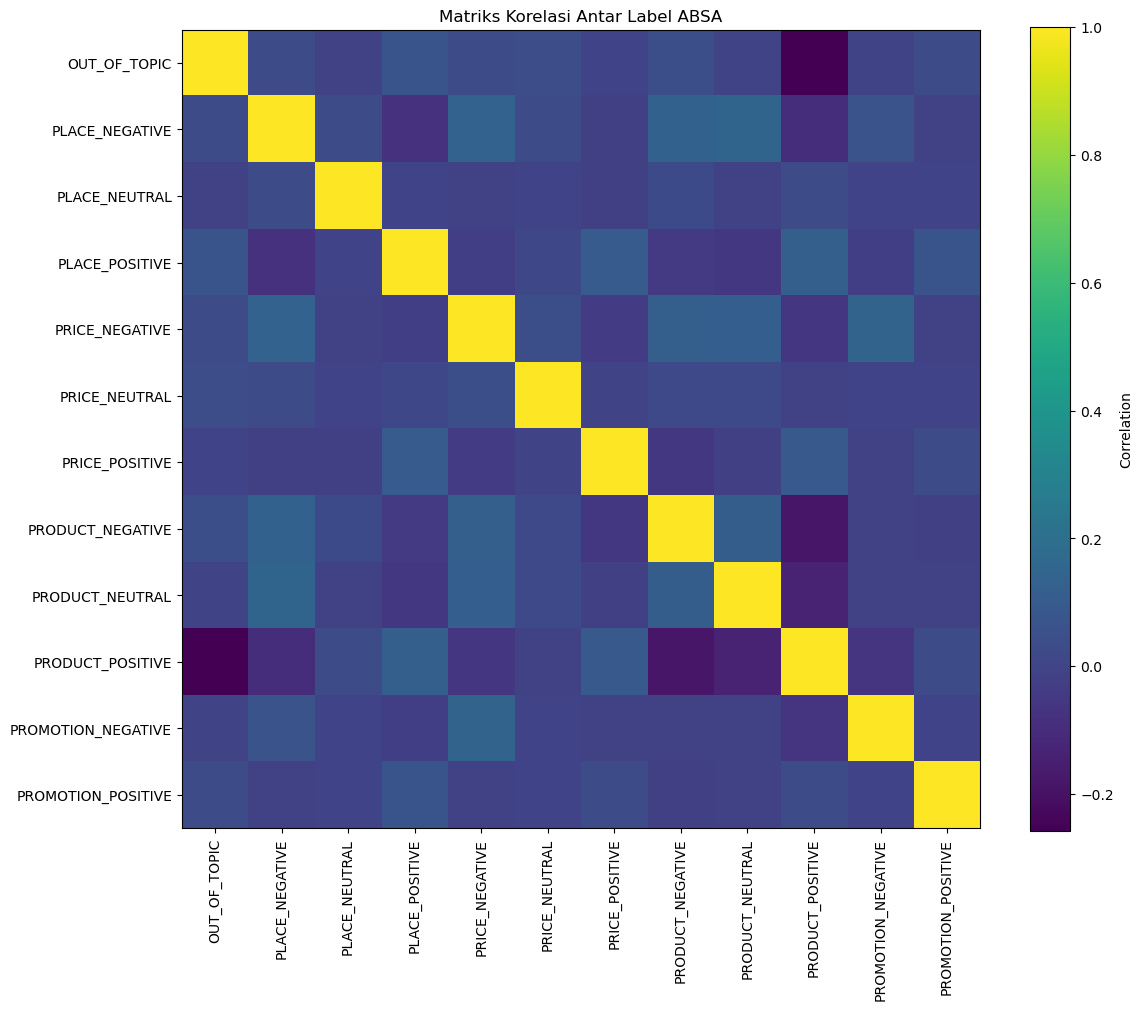

In [31]:
# Visualisasi Matriks Korelasi Antar Label

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Matriks Korelasi Antar Label ABSA")
plt.tight_layout()
plt.show()

In [32]:
# =========================
# 12. Ringkasan Statistik Dataset
# =========================

summary = {
    "jumlah_review_eda": len(df_eda),
    "jumlah_label_unik": len(label_counts),
    "jumlah_entitas": len(entity_df),
    "rata_rata_panjang_kata": df_eda["word_count"].mean(),
    "median_panjang_kata": df_eda["word_count"].median(),
    "min_panjang_kata": df_eda["word_count"].min(),
    "max_panjang_kata": df_eda["word_count"].max()
}

summary_df = pd.DataFrame([summary])

summary_df

,jumlah_review_eda,jumlah_label_unik,jumlah_entitas,rata_rata_panjang_kata,median_panjang_kata,min_panjang_kata,max_panjang_kata
0,1232,12,2862,22.609578,12.0,5,276
